# Europarl EN to FR - Transformer Training 

Experiements
- `MAX_LINES=200_000`
- 200k seed=42
- 500k seed=42
- 200k seed=13
- 200k seed=99 


In [3]:
!pip install -q sentencepiece sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.6 MB/s eta 0:00:00


In [4]:
import os, math, random, time, json, shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
import sacrebleu
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


In [5]:
DRIVE_BASE_DIR = '/content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets'
DRIVE_OK = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    os.makedirs(DRIVE_BASE_DIR, exist_ok=True)
    DRIVE_OK = True
    print(f"Drive mounted. Run artifacts will be persisted under:\n  {DRIVE_BASE_DIR}/m_training_<run_id>/")
except Exception as e:
    print(f"Drive not available ({type(e).__name__}: {e})")
    print("Continuing with local-only saves. Anything not downloaded before disconnect is lost.")

Mounted at /content/drive
Drive mounted. Run artifacts will be persisted under:
  /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_<run_id>/


In [6]:
# Download Europarl
print("Downloading Europarl EN-FR")
!wget -q -O europarl.zip https://object.pouta.csc.fi/OPUS-Europarl/v7/moses/en-fr.txt.zip
!unzip -q -o europarl.zip
!ls -la Europarl.en-fr.* 2>/dev/null
print("Done")

-rw-rw-r-- 1 root root 308075245 Dec  5  2014 Europarl.en-fr.en
-rw-rw-r-- 1 root root 354082884 Dec  5  2014 Europarl.en-fr.fr
-rw-rw-r-- 1 root root 114158575 Dec  5  2014 Europarl.en-fr.ids
Done


In [7]:
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
MAX_LEN = 64
VOCAB_SIZE = 16000

def filter_pairs(max_lines, en_file='Europarl.en-fr.en', fr_file='Europarl.en-fr.fr',
                 min_tok=1, max_tok=50, ratio_lo=0.5, ratio_hi=2.0):
    pairs = []
    with open(en_file, 'r', encoding='utf-8') as fe, open(fr_file, 'r', encoding='utf-8') as ff:
        for i, (e, f) in enumerate(zip(fe, ff)):
            if i >= max_lines:
                break
            e = e.strip().lower(); f = f.strip().lower()
            if not e or not f:
                continue
            ne, nf = len(e.split()), len(f.split())
            if not (min_tok <= ne <= max_tok and min_tok <= nf <= max_tok):
                continue
            if not (ratio_lo <= ne / nf <= ratio_hi):
                continue
            pairs.append((e, f))
    return pairs

def make_splits(pairs, n_val=3000, n_test=3000, seed=42):
    rng = random.Random(seed)
    pairs = list(pairs); rng.shuffle(pairs)
    n_train = len(pairs) - n_val - n_test
    return pairs[:n_train], pairs[n_train:n_train+n_val], pairs[n_train+n_val:]

def write_split_files(train_pairs, val_pairs, test_pairs, run_id):
    base = Path(f'data_{run_id}'); base.mkdir(exist_ok=True)
    for name, data in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
        with open(base/f'{name}.en', 'w') as fe, open(base/f'{name}.fr', 'w') as ff:
            for e, f in data:
                fe.write(e + '\n'); ff.write(f + '\n')
    spm_path = base/'spm_train.txt'
    with open(spm_path, 'w') as fo:
        for e, f in train_pairs:
            fo.write(e + '\n'); fo.write(f + '\n')
    return str(base), str(spm_path)

def train_bpe(spm_train_path, run_id, vocab_size=VOCAB_SIZE):
    spm.SentencePieceTrainer.train(
        input=spm_train_path, model_prefix=f'spm_{run_id}',
        vocab_size=vocab_size, model_type='bpe',
        pad_id=PAD_ID, unk_id=UNK_ID, bos_id=BOS_ID, eos_id=EOS_ID,
        pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>',
        character_coverage=1.0, num_threads=os.cpu_count(),
    )
    sp = spm.SentencePieceProcessor(); sp.load(f'spm_{run_id}.model')
    return sp

print('Data helpers defined.')

Data helpers defined.


In [8]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, sp, max_len=MAX_LEN):
        self.pairs = pairs; self.sp = sp; self.max_len = max_len
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        e, f = self.pairs[idx]
        src = self.sp.encode(e, out_type=int)[:self.max_len - 2]
        tgt = self.sp.encode(f, out_type=int)[:self.max_len - 2]
        return (torch.tensor([BOS_ID] + src + [EOS_ID], dtype=torch.long),
                torch.tensor([BOS_ID] + tgt + [EOS_ID], dtype=torch.long))

def collate(batch):
    srcs, tgts = zip(*batch)
    max_s = max(len(s) for s in srcs); max_t = max(len(t) for t in tgts)
    src_pad = torch.full((len(batch), max_s), PAD_ID, dtype=torch.long)
    tgt_pad = torch.full((len(batch), max_t), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_pad[i, :len(s)] = s; tgt_pad[i, :len(t)] = t
    return src_pad, tgt_pad

def build_loaders(train_pairs, val_pairs, test_pairs, sp, batch_size=128):
    return (
        DataLoader(TranslationDataset(train_pairs, sp), batch_size=batch_size, shuffle=True,
                   num_workers=2, collate_fn=collate, pin_memory=True, drop_last=True),
        DataLoader(TranslationDataset(val_pairs, sp), batch_size=batch_size, shuffle=False,
                   num_workers=2, collate_fn=collate, pin_memory=True),
        DataLoader(TranslationDataset(test_pairs, sp), batch_size=batch_size, shuffle=False,
                   num_workers=2, collate_fn=collate, pin_memory=True),
    )

print('Dataset helpers defined.')

Dataset helpers defined.


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerNMT(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_enc=6, num_dec=6,
                 dim_ff=2048, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        self.transformer = nn.Transformer(d_model=d_model, nhead=nhead,
            num_encoder_layers=num_enc, num_decoder_layers=num_dec,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True, norm_first=True)
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)
        self.fc_out.weight = self.embed.weight
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    def _emb(self, x):
        return self.dropout(self.pos(self.embed(x) * math.sqrt(self.d_model)))
    @staticmethod
    def _causal(T, dev):
        return torch.triu(torch.ones(T, T, device=dev), diagonal=1).bool()
    def forward(self, src, tgt):
        src_pad = (src == PAD_ID); tgt_pad = (tgt == PAD_ID)
        causal = self._causal(tgt.size(1), tgt.device)
        out = self.transformer(self._emb(src), self._emb(tgt),
                               tgt_mask=causal, src_key_padding_mask=src_pad,
                               tgt_key_padding_mask=tgt_pad, memory_key_padding_mask=src_pad)
        return self.fc_out(out)
    def encode(self, src):
        src_pad = (src == PAD_ID)
        memory = self.transformer.encoder(self._emb(src), src_key_padding_mask=src_pad)
        return memory, src_pad
    def decode_step(self, tgt, memory, src_pad):
        tgt_pad = (tgt == PAD_ID)
        causal = self._causal(tgt.size(1), tgt.device)
        out = self.transformer.decoder(self._emb(tgt), memory, tgt_mask=causal,
                                       tgt_key_padding_mask=tgt_pad,
                                       memory_key_padding_mask=src_pad)
        return self.fc_out(out)

class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, smoothing=0.1, ignore_index=PAD_ID):
        super().__init__()
        self.vocab_size = vocab_size; self.smoothing = smoothing
        self.ignore_index = ignore_index; self.confidence = 1.0 - smoothing
    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true = torch.full_like(log_probs, self.smoothing / (self.vocab_size - 2))
            true.scatter_(1, target.unsqueeze(1), self.confidence)
            true[:, self.ignore_index] = 0
            mask = (target == self.ignore_index)
            true.masked_fill_(mask.unsqueeze(1), 0.0)
        loss = -(true * log_probs).sum(dim=-1)
        denom = (~mask).sum().clamp(min=1)
        return loss.sum() / denom

def build_model_and_optim(vocab_size, d_model=512, warmup=4000):
    model = TransformerNMT(vocab_size, d_model=d_model).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    def noam_factor(step):
        step = max(step, 1)
        return d_model ** -0.5 * min(step ** -0.5, step * warmup ** -1.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1.0,
                                  betas=(0.9, 0.98), eps=1e-9, weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda s: noam_factor(s + 1))
    criterion = LabelSmoothingLoss(vocab_size, smoothing=0.1)
    return model, optimizer, scheduler, criterion, n_params

print('Model helpers defined.')

Model helpers defined.


In [10]:
def run_epoch(model, loader, train, optimizer, scheduler, criterion, vocab_size, print_every=200, grad_clip=1.0):
    model.train(train)
    total_loss, total_tok = 0.0, 0; t0 = time.time()
    for i, (src, tgt) in enumerate(loader):
        src = src.to(device, non_blocking=True); tgt = tgt.to(device, non_blocking=True)
        tgt_in = tgt[:, :-1]; tgt_out = tgt[:, 1:]
        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, vocab_size), tgt_out.reshape(-1))
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step(); scheduler.step()
        n_tok = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * n_tok; total_tok += n_tok
        if train and (i % print_every == 0):
            cur_lr = scheduler.get_last_lr()[0]
            print(f"  step {i:5d}/{len(loader)} | loss {loss.item():.3f} | lr {cur_lr:.2e}")
    return total_loss / max(total_tok, 1), time.time() - t0

def train_loop(model, optimizer, scheduler, criterion, train_loader, val_loader, vocab_size,
               epochs, drive_path, run_id, drive_ok):
    best_val = float('inf'); best_epoch = 0
    train_curve, val_curve, epoch_times = [], [], []
    local_best = f'best_{run_id}.pt'
    drive_best = os.path.join(drive_path, 'best.pt') if drive_ok else None
    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")
        tr_loss, tr_t = run_epoch(model, train_loader, True, optimizer, scheduler, criterion, vocab_size)
        va_loss, va_t = run_epoch(model, val_loader, False, optimizer, scheduler, criterion, vocab_size)
        train_curve.append(tr_loss); val_curve.append(va_loss); epoch_times.append(tr_t + va_t)
        print(f"  Train loss {tr_loss:.4f} (ppl {math.exp(tr_loss):6.2f}, {tr_t:5.0f}s)")
        print(f"  Val   loss {va_loss:.4f} (ppl {math.exp(va_loss):6.2f}, {va_t:5.0f}s)")
        if va_loss < best_val:
            best_val = va_loss; best_epoch = epoch
            ckpt = {'Model': model.state_dict(), 'epoch': epoch, 'val_loss': va_loss, 'run_id': run_id}
            torch.save(ckpt, local_best)
            if drive_ok:
                try:
                    torch.save(ckpt, drive_best)
                    print(f"  Saved {local_best} locally + Drive (val loss {va_loss:.4f})")
                except Exception as e:
                    print(f"  Saved {local_best} locally; Drive save FAILED ({type(e).__name__}: {e})")
            else:
                print(f"  Saved {local_best} locally only (val loss {va_loss:.4f})")
    print(f"\nBest val loss: {best_val:.4f}  (perplexity {math.exp(best_val):.2f}) at epoch {best_epoch}")
    return best_val, best_epoch, train_curve, val_curve, epoch_times

def plot_and_save_curves(train_curve, val_curve, run_id, drive_path, drive_ok):
    plt.figure(figsize=(8, 4))
    xs = list(range(1, len(train_curve) + 1))
    plt.plot(xs, train_curve, marker='o', label='train')
    plt.plot(xs, val_curve, marker='o', label='val')
    plt.xlabel('epoch'); plt.ylabel('cross-entropy loss')
    plt.title(f'Training curves — Transformer + BPE ({run_id})')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    local_png = f'curves_{run_id}.png'
    plt.savefig(local_png, dpi=120, bbox_inches='tight'); plt.show()
    if drive_ok:
        try:
            shutil.copy(local_png, os.path.join(drive_path, 'curves.png'))
            print(f"Copied {local_png} -> {drive_path}/curves.png")
        except Exception as e:
            print(f"Could not copy curves to Drive ({type(e).__name__}: {e})")

def persist_tokenizer(run_id, drive_path, drive_ok):
    if not drive_ok:
        print('Drive not mounted; skipping tokenizer persistence.'); return
    for ext, target_name in [('model', 'spm.model'), ('vocab', 'spm.vocab')]:
        src = f'spm_{run_id}.{ext}'
        if os.path.exists(src):
            try:
                shutil.copy(src, os.path.join(drive_path, target_name))
                print(f"Copied {src} -> {drive_path}/{target_name}")
            except Exception as e:
                print(f"Could not copy {src} ({type(e).__name__}: {e})")

print('Training helpers defined.')

Training helpers defined.


In [11]:
@torch.no_grad()
def greedy_decode_batch(model, src, max_len=80):
    memory, src_pad = model.encode(src)
    B = src.size(0)
    ys = torch.full((B, 1), BOS_ID, dtype=torch.long, device=device)
    finished = torch.zeros(B, dtype=torch.bool, device=device)
    for _ in range(max_len - 1):
        logits = model.decode_step(ys, memory, src_pad)
        nxt = logits[:, -1].argmax(-1)
        nxt = torch.where(finished, torch.full_like(nxt, PAD_ID), nxt)
        ys = torch.cat([ys, nxt.unsqueeze(1)], dim=1)
        finished = finished | (nxt == EOS_ID)
        if finished.all():
            break
    return ys

def ids_to_text(ids, sp):
    out = []
    for i in ids:
        i = int(i)
        if i in (BOS_ID, PAD_ID): continue
        if i == EOS_ID: break
        out.append(i)
    return sp.decode(out)

@torch.no_grad()
def eval_corpus_bleu(model, loader, sp, name):
    refs, hyps = [], []
    for src, tgt in loader:
        src = src.to(device)
        out = greedy_decode_batch(model, src, max_len=80)
        for i in range(src.size(0)):
            refs.append(ids_to_text(tgt[i].tolist(), sp))
            hyps.append(ids_to_text(out[i].tolist(), sp))
    bleu = sacrebleu.corpus_bleu(hyps, [refs])
    print(f"[{name}] BLEU = {bleu.score:.2f}  (n={len(hyps)})")
    return bleu.score, hyps, refs

@torch.no_grad()
def beam_search(model, sp, text, vocab_size, beam=5, max_len=80, len_penalty=0.6):
    model.eval()
    ids = [BOS_ID] + sp.encode(text.lower(), out_type=int)[:MAX_LEN - 2] + [EOS_ID]
    src = torch.tensor(ids, device=device).unsqueeze(0)
    memory, src_pad = model.encode(src)
    memory_b = memory.expand(beam, -1, -1).contiguous()
    src_pad_b = src_pad.expand(beam, -1).contiguous()
    seqs = torch.full((beam, 1), BOS_ID, dtype=torch.long, device=device)
    scores = torch.full((beam,), -1e9, device=device); scores[0] = 0.0
    finished = []
    for _ in range(max_len - 1):
        logits = model.decode_step(seqs, memory_b, src_pad_b)
        logp = F.log_softmax(logits[:, -1], dim=-1)
        cand = scores.unsqueeze(1) + logp
        topk = cand.view(-1).topk(beam)
        beam_idx = topk.indices // vocab_size; tok_idx = topk.indices % vocab_size
        seqs = torch.cat([seqs[beam_idx], tok_idx.unsqueeze(1)], dim=1)
        scores = topk.values
        is_eos = (tok_idx == EOS_ID)
        for b in is_eos.nonzero(as_tuple=True)[0].tolist():
            lp = ((5 + seqs.size(1)) / 6.0) ** len_penalty
            finished.append((scores[b].item() / lp, seqs[b].tolist()))
            scores[b] = -1e9
        if len(finished) >= beam:
            break
    if not finished:
        b = int(scores.argmax()); finished.append((scores[b].item(), seqs[b].tolist()))
    finished.sort(key=lambda x: -x[0])
    return ids_to_text(finished[0][1], sp)

SAMPLE_SENTENCES = [
    "resumption of the session",
    "thank you for your attention",
    "i agree with the proposal",
    "climate change is a serious problem",
    "the european parliament meets today",
    "we must protect human rights and democratic values",
    "the commission has presented a new directive on energy efficiency",
]

# ---- Persist run artifacts (metrics + per-sentence predictions) ----
def save_run_artifacts(run_id, drive_path, drive_ok, *,
                       arch, config, n_pairs, best_epoch, best_val_loss,
                       train_curve, val_curve, epoch_times,
                       val_bleu, test_bleu,
                       val_pairs, val_refs, val_hyps,
                       test_pairs, test_refs, test_hyps):
    metrics = {
        'run_id': run_id, 'arch': arch, 'config': config, 'n_pairs': n_pairs,
        'best_epoch': best_epoch, 'best_val_loss': float(best_val_loss),
        'val_bleu': float(val_bleu), 'test_bleu': float(test_bleu),
        'train_curve': [float(x) for x in train_curve],
        'val_curve':   [float(x) for x in val_curve],
        'epoch_times_s': [float(x) for x in epoch_times],
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    local_metrics = f'metrics_{run_id}.json'
    with open(local_metrics, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Wrote {local_metrics}")
    if drive_ok:
        try:
            shutil.copy(local_metrics, os.path.join(drive_path, 'metrics.json'))
            print(f"Copied -> {drive_path}/metrics.json")
        except Exception as e:
            print(f"Drive save FAILED ({type(e).__name__}: {e})")

    for split_name, pairs, refs, hyps in [('val', val_pairs, val_refs, val_hyps),
                                          ('test', test_pairs, test_refs, test_hyps)]:
        df = pd.DataFrame([
            {'idx': i, 'src': pairs[i][0], 'ref': refs[i], 'hyp': hyps[i]}
            for i in range(len(pairs))
        ])
        local_csv = f'{split_name}_predictions_{run_id}.csv'
        df.to_csv(local_csv, index=False)
        print(f"Wrote {local_csv} ({len(df)} rows)")
        if drive_ok:
            try:
                shutil.copy(local_csv, os.path.join(drive_path, f'{split_name}_predictions.csv'))
                print(f"Copied -> {drive_path}/{split_name}_predictions.csv")
            except Exception as e:
                print(f"Drive save FAILED ({type(e).__name__}: {e})")

# ---- Loaders for analytics (read-only, no GPU needed) ----
def load_run_metrics(run_id, drive_base_dir, drive_ok):
    """Return the metrics dict for a run, trying Drive first then local."""
    candidates = []
    if drive_ok:
        candidates.append(os.path.join(drive_base_dir, f'm_training_{run_id}', 'metrics.json'))
    candidates.append(f'metrics_{run_id}.json')
    for path in candidates:
        if os.path.exists(path):
            with open(path) as f:
                return json.load(f)
    raise FileNotFoundError(f"metrics for run_id={run_id} not found in {candidates}")

def load_run_predictions(run_id, split, drive_base_dir, drive_ok):
    candidates = []
    if drive_ok:
        candidates.append(os.path.join(drive_base_dir, f'm_training_{run_id}', f'{split}_predictions.csv'))
    candidates.append(f'{split}_predictions_{run_id}.csv')
    for path in candidates:
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"{split}_predictions for run_id={run_id} not found in {candidates}")

# ---- End-to-end pipeline ----
def run_full_pipeline(run_id, max_lines, epochs, batch_size, drive_base_dir, drive_ok, seed=42):
    print('=' * 72)
    print(f"Training run: {run_id}  (max_lines={max_lines:,}, epochs={epochs}, bs={batch_size}, seed={seed})")
    print('=' * 72)
    set_seed(seed)

    drive_path = os.path.join(drive_base_dir, f'm_training_{run_id}')
    if drive_ok:
        os.makedirs(drive_path, exist_ok=True)
        print(f"Drive folder: {drive_path}\n")

    print('[1/8] Filtering pairs...')
    pairs = filter_pairs(max_lines)
    print(f"      After filtering: {len(pairs):,} pairs")

    print('[2/8] Splitting train/val/test (split seed=42)...')
    train_pairs, val_pairs, test_pairs = make_splits(pairs)
    print(f"      Train: {len(train_pairs):,}  Val: {len(val_pairs):,}  Test: {len(test_pairs):,}")
    data_dir, spm_train_path = write_split_files(train_pairs, val_pairs, test_pairs, run_id)

    print(f"\n[3/8] Training BPE tokenizer (vocab=16000) -> spm_{run_id}.model ...")
    sp = train_bpe(spm_train_path, run_id)
    print(f"      Vocab size: {sp.get_piece_size()}")
    vocab_size = sp.get_piece_size()

    print(f"\n[4/8] Building dataloaders (batch_size={batch_size})...")
    train_loader, val_loader, test_loader = build_loaders(train_pairs, val_pairs, test_pairs, sp, batch_size)
    print(f"      Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")

    print('\n[5/8] Building model + optimizer...')
    model, optimizer, scheduler, criterion, n_params = build_model_and_optim(vocab_size)
    print(f"      Model parameters: {n_params/1e6:.1f}M")

    print(f"\n[6/8] Training for {epochs} epochs (dual save: local + Drive)...")
    best_val, best_epoch, train_curve, val_curve, epoch_times = train_loop(
        model, optimizer, scheduler, criterion,
        train_loader, val_loader, vocab_size, epochs, drive_path, run_id, drive_ok,
    )
    plot_and_save_curves(train_curve, val_curve, run_id, drive_path, drive_ok)
    persist_tokenizer(run_id, drive_path, drive_ok)

    print('\n[7/8] Loading best.pt and evaluating BLEU on val + test...')
    ckpt = torch.load(f'best_{run_id}.pt', map_location=device)
    model.load_state_dict(ckpt['Model']); model.eval()
    print(f"      Loaded best_{run_id}.pt (epoch {ckpt['epoch']}, val loss {ckpt['val_loss']:.4f})")
    val_bleu,  val_hyps,  val_refs  = eval_corpus_bleu(model, val_loader,  sp, 'val')
    test_bleu, test_hyps, test_refs = eval_corpus_bleu(model, test_loader, sp, 'test')

    print('\nBeam-search example translations:')
    for s in SAMPLE_SENTENCES:
        print(f"  EN: {s}")
        print(f"  FR: {beam_search(model, sp, s, vocab_size, beam=5)}")
        print()

    print('[8/8] Saving metrics.json + predictions.csv...')
    save_run_artifacts(
        run_id=run_id, drive_path=drive_path, drive_ok=drive_ok,
        arch='transformer',
        config={'max_lines': max_lines, 'epochs': epochs, 'batch_size': batch_size,
                'seed': seed, 'vocab_size': vocab_size, 'max_len': MAX_LEN,
                'd_model': 512, 'n_params': n_params},
        n_pairs={'train': len(train_pairs), 'val': len(val_pairs), 'test': len(test_pairs)},
        best_epoch=best_epoch, best_val_loss=best_val,
        train_curve=train_curve, val_curve=val_curve, epoch_times=epoch_times,
        val_bleu=val_bleu, test_bleu=test_bleu,
        val_pairs=val_pairs, val_refs=val_refs, val_hyps=val_hyps,
        test_pairs=test_pairs, test_refs=test_refs, test_hyps=test_hyps,
    )

    print('=' * 72)
    print(f"Run {run_id} complete.")
    print(f"  Val  BLEU: {val_bleu:.2f}")
    print(f"  Test BLEU: {test_bleu:.2f}")
    print(f"  Best val loss: {best_val:.4f}  (epoch {best_epoch})")
    if drive_ok:
        print(f"  Drive: {drive_path}/  (best.pt, spm.model, spm.vocab, curves.png, metrics.json, val_predictions.csv, test_predictions.csv)")
    print('=' * 72)

    return {
        'run_id': run_id, 'best_val': best_val, 'val_bleu': val_bleu, 'test_bleu': test_bleu,
        'sp': sp, 'model': model, 'drive_path': drive_path,
        'train_curve': train_curve, 'val_curve': val_curve,
        'val_hyps': val_hyps, 'val_refs': val_refs,
        'test_hyps': test_hyps, 'test_refs': test_refs,
    }

print('Inference + persistence helpers defined.')

Inference + persistence helpers defined.


### Exp 1 - 200k pairs, seed=42

Training run: 200k  (max_lines=200,000, epochs=15, bs=128, seed=42)
Drive folder: /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k

[1/8] Filtering pairs...
      After filtering: 180,289 pairs
[2/8] Splitting train/val/test (split seed=42)...
      Train: 174,289  Val: 3,000  Test: 3,000

[3/8] Training BPE tokenizer (vocab=16000) -> spm_200k.model ...
      Vocab size: 16000

[4/8] Building dataloaders (batch_size=128)...
      Train batches: 1361  Val: 24  Test: 24

[5/8] Building model + optimizer...
      Model parameters: 52.3M

[6/8] Training for 15 epochs (dual save: local + Drive)...

Epoch 1/15
  step     0/1361 | loss 9.744 | lr 3.49e-07
  step   200/1361 | loss 7.678 | lr 3.53e-05
  step   400/1361 | loss 6.362 | lr 7.02e-05
  step   600/1361 | loss 5.792 | lr 1.05e-04
  step   800/1361 | loss 5.349 | lr 1.40e-04
  step  1000/1361 | loss 5.066 | lr 1.75e-04
  step  1200/1361 | loss 4.930 | lr 2.10e-04
  Train loss 6.0622 (ppl 

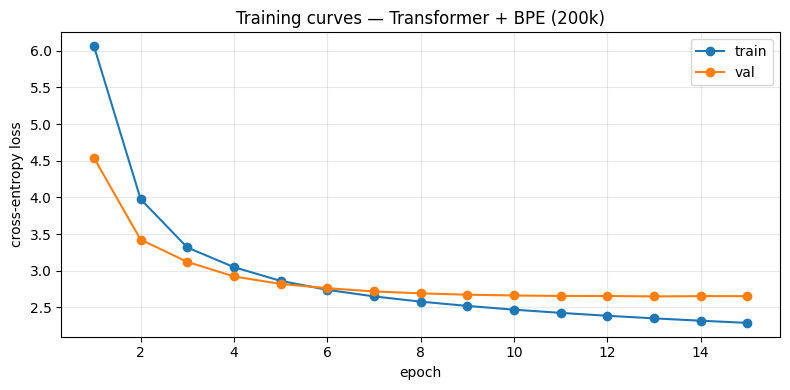

Copied curves_200k.png -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k/curves.png
Copied spm_200k.model -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k/spm.model
Copied spm_200k.vocab -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k/spm.vocab

[7/8] Loading best.pt and evaluating BLEU on val + test...
      Loaded best_200k.pt (epoch 13, val loss 2.6490)
[val] BLEU = 30.34  (n=3000)
[test] BLEU = 30.61  (n=3000)

Beam-search example translations:
  EN: resumption of the session
  FR: reprise de la session

  EN: thank you for your attention
  FR: merci pour votre attention.

  EN: i agree with the proposal
  FR: je suis d'accord avec la proposition

  EN: climate change is a serious problem
  FR: le changement climatique est un problème grave.

  EN: the european parliament meets today
  FR: le parlement européen se réunit aujourd'hu

In [10]:
result_200k = run_full_pipeline(
    run_id='200k',
    max_lines=200_000,
    epochs=15,
    batch_size=128,
    drive_base_dir=DRIVE_BASE_DIR,
    drive_ok=DRIVE_OK,
    seed=42,
)

### Exp 2 - 500k pairs, seed=42


Training run: 500k  (max_lines=500,000, epochs=15, bs=128, seed=42)
Drive folder: /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_500k

[1/8] Filtering pairs...
      After filtering: 450,967 pairs
[2/8] Splitting train/val/test (split seed=42)...
      Train: 444,967  Val: 3,000  Test: 3,000

[3/8] Training BPE tokenizer (vocab=16000) -> spm_500k.model ...
      Vocab size: 16000

[4/8] Building dataloaders (batch_size=128)...
      Train batches: 3476  Val: 24  Test: 24

[5/8] Building model + optimizer...
      Model parameters: 52.3M

[6/8] Training for 15 epochs (dual save: local + Drive)...

Epoch 1/15
  step     0/3476 | loss 9.708 | lr 3.49e-07
  step   200/3476 | loss 7.609 | lr 3.53e-05
  step   400/3476 | loss 6.323 | lr 7.02e-05
  step   600/3476 | loss 5.803 | lr 1.05e-04
  step   800/3476 | loss 5.338 | lr 1.40e-04
  step  1000/3476 | loss 5.079 | lr 1.75e-04
  step  1200/3476 | loss 4.727 | lr 2.10e-04
  step  1400/3476 | loss 

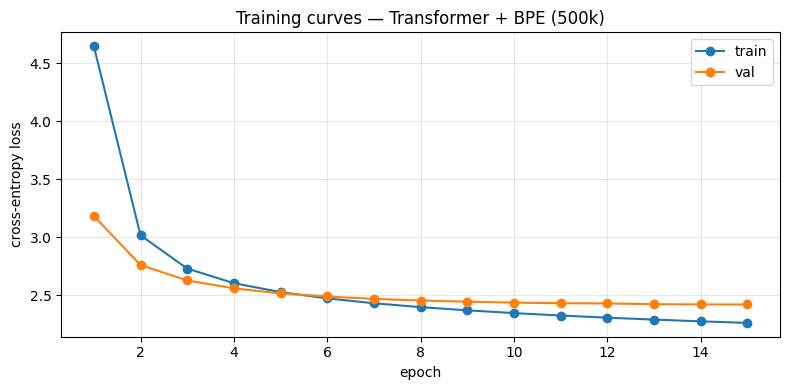

Copied curves_500k.png -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_500k/curves.png
Copied spm_500k.model -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_500k/spm.model
Copied spm_500k.vocab -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_500k/spm.vocab

[7/8] Loading best.pt and evaluating BLEU on val + test...
      Loaded best_500k.pt (epoch 15, val loss 2.4182)
[val] BLEU = 33.96  (n=3000)
[test] BLEU = 34.56  (n=3000)

Beam-search example translations:
  EN: resumption of the session
  FR: reprise de la session

  EN: thank you for your attention
  FR: merci pour votre attention

  EN: i agree with the proposal
  FR: je suis d'accord avec la proposition

  EN: climate change is a serious problem
  FR: le changement climatique est un grave problème.

  EN: the european parliament meets today
  FR: le parlement européen se réunit aujourd'hui

In [13]:
result_500k = run_full_pipeline(
    run_id='500k',
    max_lines=500_000,
    epochs=15,
    batch_size=128,
    drive_base_dir=DRIVE_BASE_DIR,
    drive_ok=DRIVE_OK,
    seed=42,
)

### Exp 3 - 200k pairs, seed=13 


Training run: 200k_s13  (max_lines=200,000, epochs=15, bs=128, seed=13)
Drive folder: /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s13

[1/8] Filtering pairs...
      After filtering: 180,289 pairs
[2/8] Splitting train/val/test (split seed=42)...
      Train: 174,289  Val: 3,000  Test: 3,000

[3/8] Training BPE tokenizer (vocab=16000) -> spm_200k_s13.model ...
      Vocab size: 16000

[4/8] Building dataloaders (batch_size=128)...
      Train batches: 1361  Val: 24  Test: 24

[5/8] Building model + optimizer...
      Model parameters: 52.3M

[6/8] Training for 15 epochs (dual save: local + Drive)...

Epoch 1/15
  step     0/1361 | loss 9.710 | lr 3.49e-07
  step   200/1361 | loss 7.627 | lr 3.53e-05
  step   400/1361 | loss 6.337 | lr 7.02e-05
  step   600/1361 | loss 5.697 | lr 1.05e-04
  step   800/1361 | loss 5.428 | lr 1.40e-04
  step  1000/1361 | loss 5.156 | lr 1.75e-04
  step  1200/1361 | loss 4.847 | lr 2.10e-04
  Train loss 

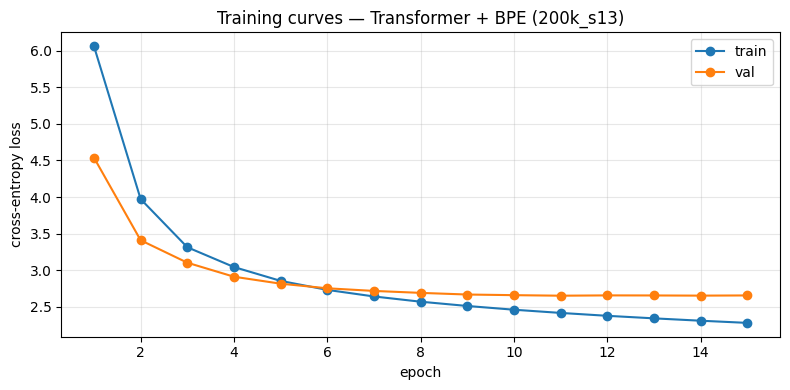

Copied curves_200k_s13.png -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s13/curves.png
Copied spm_200k_s13.model -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s13/spm.model
Copied spm_200k_s13.vocab -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s13/spm.vocab

[7/8] Loading best.pt and evaluating BLEU on val + test...
      Loaded best_200k_s13.pt (epoch 11, val loss 2.6535)
[val] BLEU = 30.22  (n=3000)
[test] BLEU = 30.17  (n=3000)

Beam-search example translations:
  EN: resumption of the session
  FR: reprise de la session

  EN: thank you for your attention
  FR: merci de votre attention

  EN: i agree with the proposal
  FR: je suis d'accord avec la proposition

  EN: climate change is a serious problem
  FR: le changement climatique est un problème sérieux.

  EN: the european parliament meets today
  FR: le parlement eu

In [11]:
result_200k_s13 = run_full_pipeline(
    run_id='200k_s13',
    max_lines=200_000,
    epochs=15,
    batch_size=128,
    drive_base_dir=DRIVE_BASE_DIR,
    drive_ok=DRIVE_OK,
    seed=13,
)

### Exp 4 - 200k pairs, seed=99 

Training run: 200k_s99  (max_lines=200,000, epochs=15, bs=128, seed=99)
Drive folder: /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s99

[1/8] Filtering pairs...
      After filtering: 180,289 pairs
[2/8] Splitting train/val/test (split seed=42)...
      Train: 174,289  Val: 3,000  Test: 3,000

[3/8] Training BPE tokenizer (vocab=16000) -> spm_200k_s99.model ...
      Vocab size: 16000

[4/8] Building dataloaders (batch_size=128)...
      Train batches: 1361  Val: 24  Test: 24

[5/8] Building model + optimizer...
      Model parameters: 52.3M

[6/8] Training for 15 epochs (dual save: local + Drive)...

Epoch 1/15
  step     0/1361 | loss 9.706 | lr 3.49e-07
  step   200/1361 | loss 7.637 | lr 3.53e-05
  step   400/1361 | loss 6.391 | lr 7.02e-05
  step   600/1361 | loss 5.833 | lr 1.05e-04
  step   800/1361 | loss 5.447 | lr 1.40e-04
  step  1000/1361 | loss 5.138 | lr 1.75e-04
  step  1200/1361 | loss 4.851 | lr 2.10e-04
  Train loss 

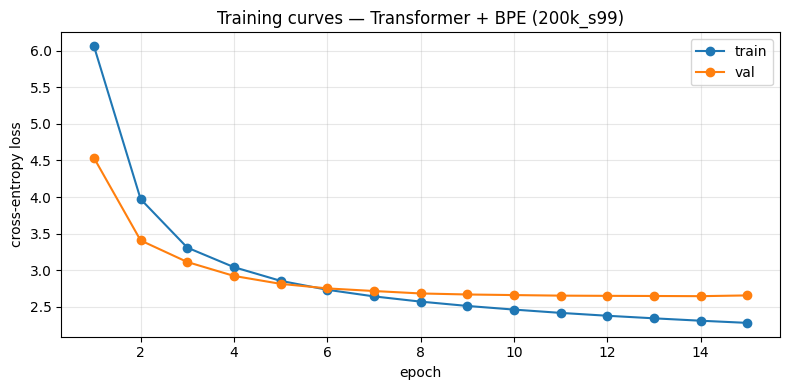

Copied curves_200k_s99.png -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s99/curves.png
Copied spm_200k_s99.model -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s99/spm.model
Copied spm_200k_s99.vocab -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_200k_s99/spm.vocab

[7/8] Loading best.pt and evaluating BLEU on val + test...
      Loaded best_200k_s99.pt (epoch 14, val loss 2.6460)
[val] BLEU = 30.49  (n=3000)
[test] BLEU = 30.52  (n=3000)

Beam-search example translations:
  EN: resumption of the session
  FR: reprise de la session

  EN: thank you for your attention
  FR: merci de votre attention

  EN: i agree with the proposal
  FR: je suis d'accord avec la proposition

  EN: climate change is a serious problem
  FR: le changement climatique est un problème sérieux.

  EN: the european parliament meets today
  FR: le parlement eu

In [12]:
result_200k_s99 = run_full_pipeline(
    run_id='200k_s99',
    max_lines=200_000,
    epochs=15,
    batch_size=128,
    drive_base_dir=DRIVE_BASE_DIR,
    drive_ok=DRIVE_OK,
    seed=99,
)

### Analytics

In [14]:
ALL_RUNS = ['200k', '500k', '200k_s13', '200k_s99', 'lstm']

metrics_dict = {}
for rid in ALL_RUNS:
    try:
        metrics_dict[rid] = load_run_metrics(rid, DRIVE_BASE_DIR, DRIVE_OK)
        m = metrics_dict[rid]
        print(f"  loaded {rid:<10}  arch={m['arch']:<11}  val_bleu={m['val_bleu']:5.2f}  test_bleu={m['test_bleu']:5.2f}")
    except FileNotFoundError:
        print(f"  skipping {rid:<10}  (metrics not found — run the corresponding cell first or remove from ALL_RUNS)")

print(f"\nLoaded {len(metrics_dict)} run(s) for analysis.")

  loaded 200k        arch=transformer  val_bleu=30.34  test_bleu=30.61
  loaded 500k        arch=transformer  val_bleu=33.96  test_bleu=34.56
  loaded 200k_s13    arch=transformer  val_bleu=30.22  test_bleu=30.17
  loaded 200k_s99    arch=transformer  val_bleu=30.49  test_bleu=30.52
  skipping lstm        (metrics not found — run the corresponding cell first or remove from ALL_RUNS)

Loaded 4 run(s) for analysis.


In [15]:
# Summary DataFrame
rows = []
for rid, m in metrics_dict.items():
    rows.append({
        'run_id':        rid,
        'arch':          m['arch'],
        'max_lines':     m['config']['max_lines'],
        'seed':          m['config']['seed'],
        'n_train':       m['n_pairs']['train'],
        'n_params_M':    round(m['config']['n_params'] / 1e6, 1),
        'epochs':        m['config']['epochs'],
        'best_epoch':    m['best_epoch'],
        'best_val_loss': round(m['best_val_loss'], 4),
        'val_bleu':      round(m['val_bleu'], 2),
        'test_bleu':     round(m['test_bleu'], 2),
        'total_min':     round(sum(m.get('epoch_times_s', [])) / 60, 1),
    })

summary_df = pd.DataFrame(rows)
if len(summary_df):
    summary_df = summary_df.sort_values(['arch', 'max_lines', 'seed']).reset_index(drop=True)
    print('Per-run summary:\n')
    print(summary_df.to_string(index=False))
    summary_df.to_csv('analysis_summary.csv', index=False)
    print('\n(also written to analysis_summary.csv)')
else:
    print('No runs loaded — run a training cell first.')

Per-run summary:

  run_id        arch  max_lines  seed  n_train  n_params_M  epochs  best_epoch  best_val_loss  val_bleu  test_bleu  total_min
200k_s13 transformer     200000    13   174289        52.3      15          11         2.6535     30.22      30.17       21.2
    200k transformer     200000    42   174289        52.3      15          13         2.6490     30.34      30.61       21.3
200k_s99 transformer     200000    99   174289        52.3      15          14         2.6460     30.49      30.52       21.1
    500k transformer     500000    42   444967        52.3      15          15         2.4182     33.96      34.56       53.5

(also written to analysis_summary.csv)


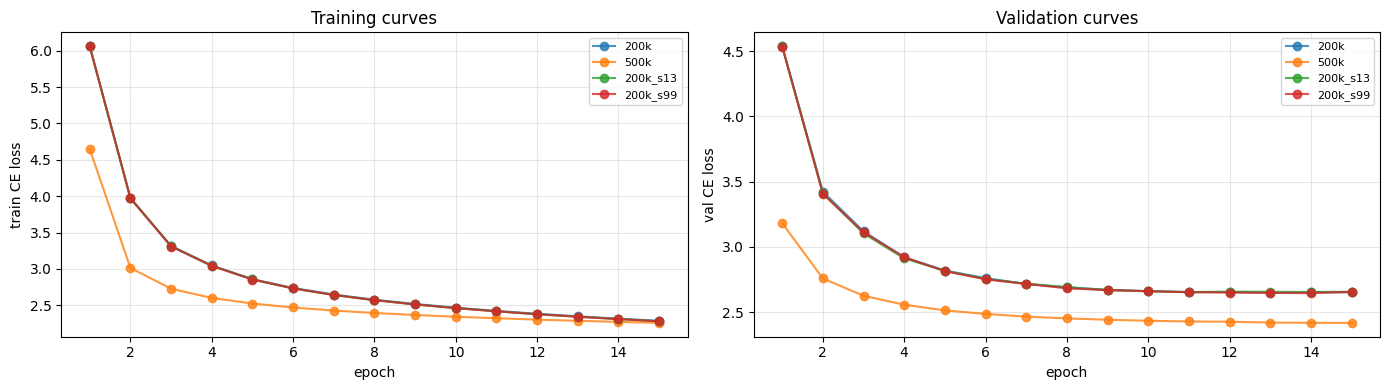

Saved analysis_curves_overlay.png


In [16]:
# Shows convergence speed and final - Validation curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for rid, m in metrics_dict.items():
    epochs = list(range(1, len(m['val_curve']) + 1))
    axes[0].plot(epochs, m['train_curve'], marker='o', label=rid, alpha=0.8)
    axes[1].plot(epochs, m['val_curve'],   marker='o', label=rid, alpha=0.8)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train CE loss'); axes[0].set_title('Training curves')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val CE loss');   axes[1].set_title('Validation curves')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('analysis_curves_overlay.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved analysis_curves_overlay.png')

In [17]:
seed_runs = {rid: m for rid, m in metrics_dict.items()
             if m['arch'] == 'transformer' and m['config']['max_lines'] == 200_000}

if len(seed_runs) >= 2:
    val_bleus  = np.array([m['val_bleu']  for m in seed_runs.values()])
    test_bleus = np.array([m['test_bleu'] for m in seed_runs.values()])
    seeds      = [m['config']['seed'] for m in seed_runs.values()]
    print(f"Transformer 200k multi-seed (n={len(seed_runs)}, seeds={seeds}):")
    print(f"  Val  BLEU: {val_bleus.mean():.2f} ± {val_bleus.std(ddof=1):.2f}    "
          f"(min {val_bleus.min():.2f}, max {val_bleus.max():.2f})")
    print(f"  Test BLEU: {test_bleus.mean():.2f} ± {test_bleus.std(ddof=1):.2f}    "
          f"(min {test_bleus.min():.2f}, max {test_bleus.max():.2f})")
    print('\nReport this as: "BLEU = <mean> ± <std> over n=<n> seeds".')
elif len(seed_runs) == 1:
    rid = next(iter(seed_runs))
    print(f"Only 1 seed loaded ({rid}, seed={seed_runs[rid]['config']['seed']}). "
          f"Run two more seeds (Run C and Run D above) to get a confidence interval.")
else:
    print('No 200k Transformer runs loaded — run Run A, C, D first.')

Transformer 200k multi-seed (n=3, seeds=[42, 13, 99]):
  Val  BLEU: 30.35 ± 0.14    (min 30.22, max 30.49)
  Test BLEU: 30.43 ± 0.23    (min 30.17, max 30.61)

Report this as: "BLEU = <mean> ± <std> over n=<n> seeds".


In [18]:
import sacrebleu

LENGTH_BINS = [0, 5, 10, 15, 20, 30, 50, 200]

len_rows = []
for rid in metrics_dict:
    try:
        df = load_run_predictions(rid, 'test', DRIVE_BASE_DIR, DRIVE_OK)
    except FileNotFoundError:
        print(f"  no test_predictions for {rid}, skipping")
        continue
    df['src_len'] = df['src'].str.split().str.len()
    df['bucket'] = pd.cut(df['src_len'], bins=LENGTH_BINS)
    for bucket, group in df.groupby('bucket', observed=True):
        if len(group) == 0: continue
        bleu = sacrebleu.corpus_bleu(group['hyp'].tolist(), [group['ref'].tolist()]).score
        len_rows.append({'run_id': rid, 'src_len_bucket': str(bucket), 'n': len(group), 'bleu': round(bleu, 2)})

if len_rows:
    length_df = pd.DataFrame(len_rows)
    pivot = length_df.pivot(index='src_len_bucket', columns='run_id', values='bleu')
    print('Test BLEU by source-length bucket (English words):\n')
    print(pivot.to_string())
    pivot.to_csv('analysis_bleu_by_length.csv')
    print('\n(also written to analysis_bleu_by_length.csv)')
else:
    print('No predictions loaded — run a training cell first.')

Test BLEU by source-length bucket (English words):

run_id           200k  200k_s13  200k_s99   500k
src_len_bucket                                  
(0, 5]          57.61     55.39     55.97  61.79
(10, 15]        31.05     30.93     31.71  34.24
(15, 20]        30.38     28.54     29.38  35.26
(20, 30]        29.57     29.63     29.82  33.94
(30, 50]        30.59     30.19     30.28  34.33
(5, 10]         34.41     34.32     35.49  35.77

(also written to analysis_bleu_by_length.csv)


In [19]:
RUN_A = '200k'
RUN_B = '500k'

if RUN_A in metrics_dict and RUN_B in metrics_dict:
    df_a = load_run_predictions(RUN_A, 'test', DRIVE_BASE_DIR, DRIVE_OK)
    df_b = load_run_predictions(RUN_B, 'test', DRIVE_BASE_DIR, DRIVE_OK)
    cmp = df_a.merge(df_b, on=['idx', 'src', 'ref'], suffixes=(f'_{RUN_A}', f'_{RUN_B}'))
    # Sisagreement signals
    cmp['disagreement'] = (cmp[f'hyp_{RUN_A}'].fillna('').str.len()
                            - cmp[f'hyp_{RUN_B}'].fillna('').str.len()).abs() \
                          + cmp.apply(lambda r: 0 if str(r[f'hyp_{RUN_A}']) == str(r[f'hyp_{RUN_B}']) else 1, axis=1) * 50
    top_diffs = cmp.sort_values('disagreement', ascending=False).head(5)
    print(f"Top-5 sentences where {RUN_A} and {RUN_B} disagree most:\n")
    for _, r in top_diffs.iterrows():
        print(f"EN:  {r['src']}")
        print(f"REF: {r['ref']}")
        print(f"  [{RUN_A}] {r[f'hyp_{RUN_A}']}")
        print(f"  [{RUN_B}] {r[f'hyp_{RUN_B}']}")
        print()
else:
    have = sorted(metrics_dict.keys())
    print(f"Need both {RUN_A} and {RUN_B} loaded. Currently loaded: {have}")

Top-5 sentences where 200k and 500k disagree most:

